In [113]:
# Importação da biblioteca para possibilitar a leitura do csv com a base de dados
import pandas as pd

caminho_dados = 'https://raw.githubusercontent.com/AnaRaquelCafe/POSTECH_AI_SCIENTIST/refs/heads/main/Base%20de%20dados%20Tech%20Challenge/desafio_nps_fase_1.csv'

df = pd.read_csv(caminho_dados)

df.head(10)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9
5,6,35,Sudeste,75,50006,568.76,6,36.58,3,4,5,41.82,2,2,3,0.9,0,5,1.5
6,7,37,Sudeste,68,50007,41.29,3,99.62,6,8,3,35.83,3,3,4,1.4,0,6,0.6
7,8,60,Sul,37,50008,428.76,4,29.54,10,11,5,44.50,1,0,2,0.0,0,2,4.1
8,9,40,Sul,60,50009,121.56,3,91.95,6,6,3,24.88,2,1,9,6.2,0,3,0.8
9,10,51,Sudeste,70,50010,411.01,6,37.47,3,9,2,30.59,1,0,7,2.7,0,2,4.2


In [114]:
# Checagem do tamanho da base
print(df.shape)

(2500, 19)


In [115]:
# Checagem das informações prévias e característica das colunas da base
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [116]:
# Verificação de possíveis dados nulos
df.isnull().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

In [117]:
# Como não foram identificados valores nulos, o próximo passo é identificar possíveis linhas duplicadas
df.duplicated().sum()

np.int64(0)

In [118]:
# Confirmamos que o identificador único dos pedidos não possui duplicatas
df.duplicated(['order_id']).sum()

np.int64(0)

In [119]:
# Verificar a quantidade de clientes únicos presentes na base
df['customer_id'].nunique()

2500

In [120]:
# Avaliar estatísticas iniciais, onde o .T serve para transpor a tabela e facilitar a leitura na tela
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,2500.0,1250.500000,721.832160,1.00,625.7500,1250.500,1875.2500,2500.00
customer_age,2500.0,43.396000,14.888487,18.00,31.0000,43.000,56.0000,69.00
customer_tenure_months,2500.0,61.322400,34.478729,1.00,31.0000,62.000,91.0000,119.00
order_id,2500.0,51250.500000,721.832160,50001.00,50625.7500,51250.500,51875.2500,52500.00
order_value,2500.0,434.259740,289.772497,7.76,220.2450,375.515,577.2900,1983.81
items_quantity,2500.0,3.470800,1.687331,1.00,2.0000,3.000,5.0000,6.00
discount_value,2500.0,29.745620,29.225603,0.02,8.8850,20.935,40.8325,230.33
payment_installments,2500.0,6.004000,3.159743,1.00,3.0000,6.000,9.0000,11.00
delivery_time_days,2500.0,8.022000,3.770411,2.00,5.0000,8.000,11.0000,14.00
delivery_delay_days,2500.0,2.187200,1.454442,0.00,1.0000,2.000,3.0000,8.00


In [121]:
# Vale dar uma olhada breve em como estão também as estatísticas da nossa única variável categórica
df.describe(exclude='number')

,customer_region
count,2500
unique,5
top,Sul
freq,521


In [122]:
# Um tópico interessante de se entender é quantos clientes voltaram a comprar após 30 dias
print(df['repeat_purchase_30d'].value_counts())
print(df['repeat_purchase_30d'].value_counts(normalize=True) * 100)

repeat_purchase_30d
0    2282
1     218
Name: count, dtype: int64
repeat_purchase_30d
0    91.28
1     8.72
Name: proportion, dtype: float64


In [123]:
# De acordo com as estatísticas e demais avaliações, as colunas não aparentam possuir valores discrepantes ou que não fazem sentido num primeiro momento. 
# Porém, existem alguns pontos de atenção:
#  -o tempo médio de resolução dos problemas gira em torno de 5 dias, o que pode se considerar um tempo relativamente grande;
#  -o score interno de satisfação do cliente tem uma média muito baixa (abaixo de 3 num máximo de 10), o que pode indicar uma falha na execução operacional;
#  -outro que possui média baixa é o próprio NPS, com uma nota média abaixo de 5 num valor máximo de 10;
#  -vale destacar ainda a identificação que mais de 90% dos clientes da base não voltaram a comprar 30 dias após o pedido.


In [124]:
# Seguindo com a ideia de avaliar o NPS, uma boa prática agora seria dividir os clientes em grupos de acordo com essa variável
def categorizar_nps(score):
    if score >= 9.0:
        return 'Promotor'
    elif score >= 7.0:
        return 'Neutro'
    else:
        return 'Detrator'

df['grupo_nps'] = df['nps_score'].apply(categorizar_nps)

print(df['grupo_nps'].value_counts())
print(df['grupo_nps'].value_counts(normalize=True) * 100)

grupo_nps
Detrator    2109
Neutro       281
Promotor     110
Name: count, dtype: int64
grupo_nps
Detrator    84.36
Neutro      11.24
Promotor     4.40
Name: proportion, dtype: float64


In [125]:
# O retorno para cada divisão de grupos do NPS confirma a suspeita anterior de que a maioria de clientes da nossa base não aparenta satisfação com os serviços prestados,
# visto que 84,36% dos clientes foram classificados como detratores (NPS abaixo de 7) e apenas 4,40% como promotores (NPS acima ou igual a 9)

In [126]:
# Temos alguns indicadores na nossa base que podem nos indicar o caminho do problema para um NPS tão baixo na maioria dos clientes. 
# Vamos avalia-los separadamente na sequência. Mas antes, vale renomearmos as colunas para o nosso idioma
df = df.rename(
    columns={
        'nps_score': 'nota_nps',
        'delivery_time_days': 'tempo_entrega_dias',
        'delivery_delay_days': 'dias_atraso_entrega',
        'delivery_attempts': 'tentativas_entrega',
        'customer_service_contacts': 'contatos_sac',
        'resolution_time_days': 'tempo_resolucao_dias',
        'complaints_count': 'qtd_reclamacoes',
        'customer_age': 'idade_cliente',
        'customer_tenure_months': 'tempo_relacionamento_cliente',
        'order_value': 'valor_pedido',
        'items_quantity': 'quantidade_itens',
        'discount_value': 'desconto_pedido',
        'freight_value': 'valor_frete',
        'csat_internal_score': 'nota_csat',
        'customer_region': 'regiao_cliente',
        'order_id': 'id_pedido'
    }
)

colunas_operacionais = [
    'tempo_entrega_dias'
  , 'dias_atraso_entrega'
  , 'tentativas_entrega'
  , 'contatos_sac'
  , 'tempo_resolucao_dias'
  , 'qtd_reclamacoes'
  ]

media_por_grupo = df.groupby('grupo_nps')[colunas_operacionais].mean()
media_por_grupo

,tempo_entrega_dias,dias_atraso_entrega,tentativas_entrega,contatos_sac,tempo_resolucao_dias,qtd_reclamacoes
grupo_nps,,,,,,
Detrator,7.994310,2.414889,1.997155,1.632053,5.694642,4.442390
Neutro,8.263345,1.053381,2.010676,1.007117,4.615658,2.693950
Promotor,7.936364,0.718182,2.154545,0.672727,3.700000,2.272727


In [127]:
# Vamos avaliar a dias_atraso_entrega que apresentou uma variação grande entre um cliente considerado detrator e um promotor
nps_por_atraso = df.groupby('dias_atraso_entrega')['nota_nps'].agg(['mean', 'count']).reset_index()
nps_por_atraso.columns = ['dias_de_atraso', 'nps_medio', 'qtd_pedidos']

nps_por_atraso

,dias_de_atraso,nps_medio,qtd_pedidos
0,0,6.856679,277
1,1,5.546179,615
2,2,4.580186,646
3,3,3.436762,525
4,4,2.444444,270
5,5,1.481034,116
6,6,1.097059,34
7,7,0.292857,14
8,8,0.000000,3


In [128]:
# Outra variável que vale dar uma olhada melhor é a qtd_reclamacoes, pela grande variação entre um cliente promotor e detrator também. 
# Vamos olhar ela em conjunto com a dias_atraso_entrega, para identificar uma possível correlação entre elas e a nota do NPS
nps_por_reclamacoes = df.groupby('qtd_reclamacoes').agg(
    nps_medio=('nota_nps', 'mean'),
    atraso_medio_dias=('dias_atraso_entrega', 'mean')
).reset_index()

nps_por_reclamacoes

,qtd_reclamacoes,nps_medio,atraso_medio_dias
0,0,8.517391,0.000000
1,1,7.770492,1.024590
2,2,6.052347,1.797834
3,3,4.910059,2.193294
4,4,4.219167,2.353333
5,5,3.645270,2.380631
6,6,3.062030,2.379699
7,7,2.813609,2.414201
8,8,2.065079,2.507937
9,9,2.487500,2.125000


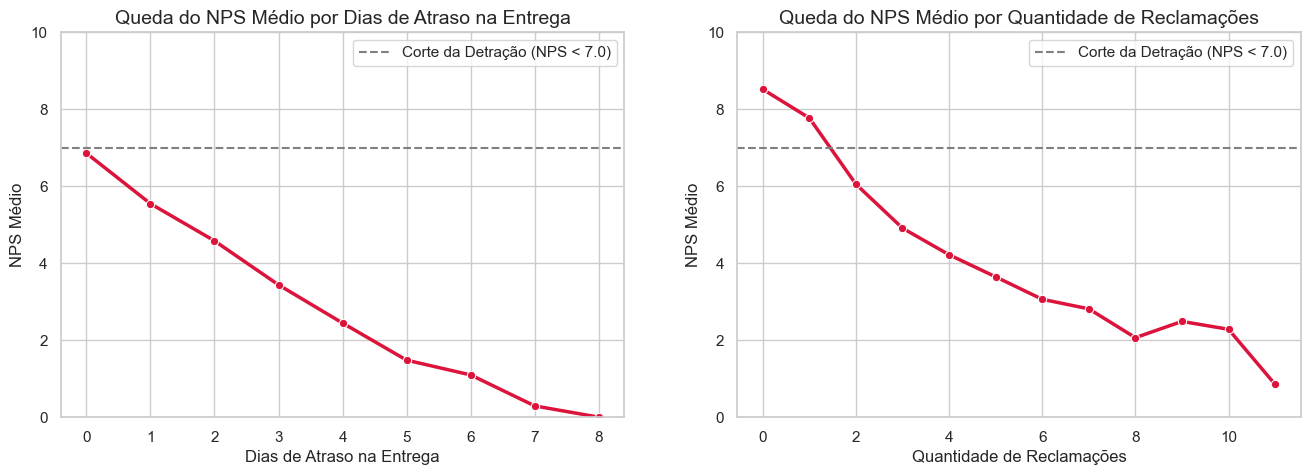

In [129]:
# Vamos gerar dois gráficos para visualizar o quanto os dias de atraso e as quantidades de reclamações, isoladamente, impactam na queda do NPS
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Primeiro o código para gerar o gráfico de NPS por atraso
sns.lineplot(
    data=nps_por_atraso, 
    x='dias_de_atraso', 
    y='nps_medio', 
    marker='o', 
    color='crimson', 
    linewidth=2.5,
    ax=axes[0]
)

# Adicionar uma linha tracejada horizontal no NPS = 7
axes[0].axhline(y=7.0, color='gray', linestyle='--', label='Corte da Detração (NPS < 7.0)')

axes[0].set_title('Queda do NPS Médio por Dias de Atraso na Entrega', fontsize=14)
axes[0].set_xlabel('Dias de Atraso na Entrega', fontsize=12)
axes[0].set_ylabel('NPS Médio', fontsize=12)
axes[0].set_ylim(0, 10)
axes[0].legend()

# Agora o gráfico para ver o NPS por quantidade de reclamações
sns.lineplot(
    data=nps_por_reclamacoes, 
    x='qtd_reclamacoes', 
    y='nps_medio', 
    marker='o', 
    color='crimson', 
    linewidth=2.5,
    ax=axes[1]
)

# Adicionar uma linha tracejada horizontal no NPS = 7
axes[1].axhline(y=7.0, color='gray', linestyle='--', label='Corte da Detração (NPS < 7.0)')

axes[1].set_title('Queda do NPS Médio por Quantidade de Reclamações', fontsize=14)
axes[1].set_xlabel('Quantidade de Reclamações', fontsize=12)
axes[1].set_ylabel('NPS Médio', fontsize=12)
axes[1].set_ylim(0, 10)
axes[1].legend()

plt.savefig('../reports/figures/queda_do_nps_medio_por_dias_de_atraso_e_qtd_reclamacoes.png', dpi=300, bbox_inches='tight')

plt.show()

In [130]:
# Vamos avaliar quem teve 0 dias de atraso, pois se repararmos, mesmo quem teve nenhum atraso a nota foi relativamente baixa (menor que 7)
atraso_zero = df[df['dias_atraso_entrega'] == 0]

# Ver a média das outras variáveis de fricção nesse grupo específico
print(atraso_zero[['contatos_sac', 'tempo_resolucao_dias', 'qtd_reclamacoes', 'nota_nps']].mean())

contatos_sac            1.545126
tempo_resolucao_dias    5.685921
qtd_reclamacoes         2.956679
nota_nps                6.856679
dtype: float64


In [131]:
# Pelo resultado acima podemos notar que, apesar de não ocorrerem atrasos para esses clientes, eles registram quase 3 reclamações em média e precisam esperar 5,68 dias para terem 
# seus problemas resolvidos. Ou seja, a entrega no prazo evita a catástrofe total, mas não salva de uma avaliação ruim visto os problemas com o pós-venda

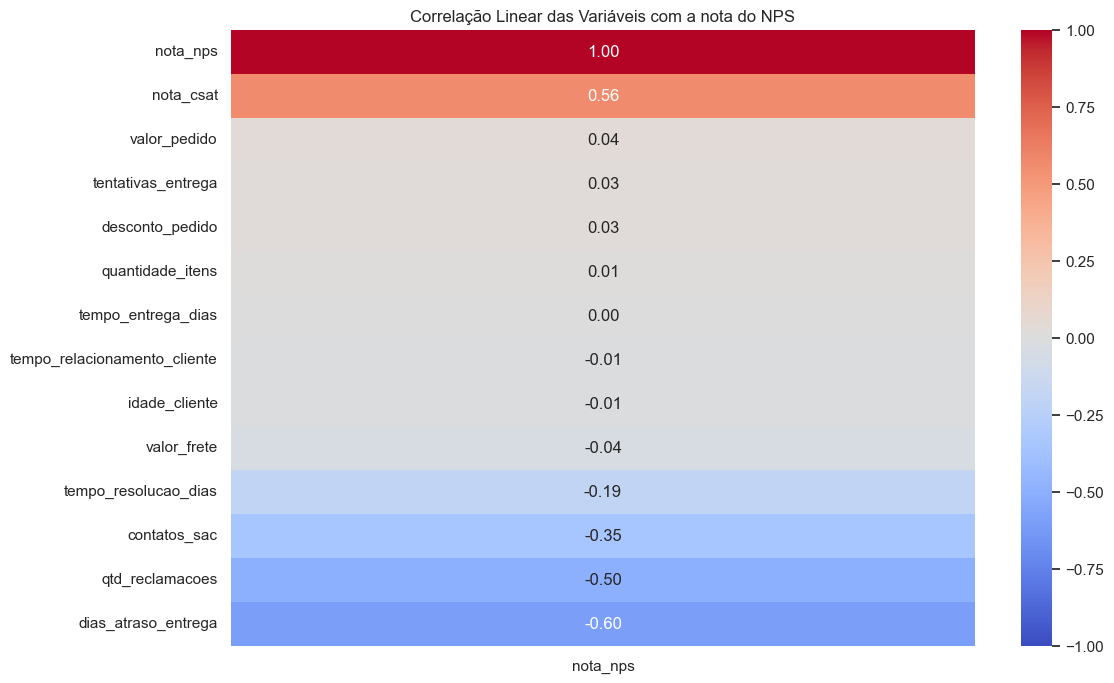

In [132]:
# Cabe agora gerar um mapa de calor de correlação entre as variáveis, para ver se a nossa análise até aqui está coerente
# Selecionar variáveis numéricas relevantes
cols_analise = [
    'idade_cliente', 'tempo_relacionamento_cliente', 'valor_pedido', 'quantidade_itens',
    'desconto_pedido', 'tempo_entrega_dias', 'dias_atraso_entrega', 'valor_frete',
    'tentativas_entrega', 'contatos_sac', 'tempo_resolucao_dias',
    'qtd_reclamacoes', 'nota_csat', 'nota_nps'
]

plt.figure(figsize=(12, 8))
correlation_matrix = df[cols_analise].corr()

# Desenhar o heatmap focando na relação das variáveis com o NPS
sns.heatmap(correlation_matrix[['nota_nps']].sort_values(by='nota_nps', ascending=False), 
            annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title('Correlação Linear das Variáveis com a nota do NPS')

plt.savefig('../reports/figures/correlacao_nps.png', dpi=300, bbox_inches='tight')

plt.show()

In [133]:
# Sempre bom pontuar que correlação não é causalidade. Posto isso, avaliando o mapa de calor, vemos que o atraso nas entregas, o número de reclamações, o número 
# de contatos do cliente com o atendimento e o tempo de resolução de problemas, tendem a ser os principais responsáveis pelas avaliações baixas de NPS. 
# Isso indica que o ponto de ruptura passa por essas 4 variáveis intrínsecas ao negócio, sendo elas complementares para explicar o problema a ser resolvido

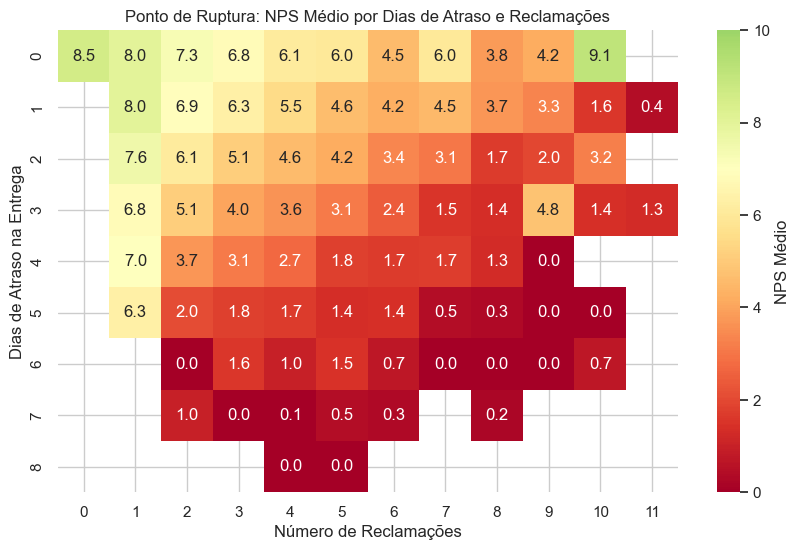

In [134]:
# Vamos gerar um gráfico que nos dê uma visão das duas principais variáveis que indicam uma correlação negativa na nota do nosso NPS, que são 
# os dias de atraso na entrega e a quantidade de reclamações. A intenção aqui é verificar o impacto da análise dessas duas variáveis em conjunto agora 
# e não seus resultados individualmente

# Pivotar os dados cruzando atraso vs reclamações calculando a média do NPS
matriz_nps = df.pivot_table(
    index="dias_atraso_entrega",
    columns="qtd_reclamacoes",
    values="nota_nps",
    aggfunc="mean",
)

plt.figure(figsize=(10, 6))

# Gerar o mapa de calor (usando paleta diverge com centro em 7)
sns.heatmap(
    matriz_nps,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    vmax=10,
    vmin=0,
    center=7.0,
    cbar_kws={'label': 'NPS Médio'},
)

plt.title('Ponto de Ruptura: NPS Médio por Dias de Atraso e Reclamações')
plt.xlabel('Número de Reclamações')
plt.ylabel('Dias de Atraso na Entrega')

plt.savefig('../reports/figures/ponto_de_ruptura.png', dpi=300, bbox_inches='tight')

plt.show()

In [135]:
# O mapa de calor nos dá uma visão bastante clara do quanto as duas variáveis avaliadas caminham em conjunto no sentido 
# de um NPS maior ou menor. Porém, salta aos olhos a nota de NPS médio que aparece para reclamações entre 9 e 10 com atraso entre 0 
# e 1 dia. Pela lógica, essa nota não deveria ser tão alta assim, o que nos faz pensar que se trata de um outlier e que outros devem 
# existir. Vamos olhar isso com mais atenção

In [136]:
# Gerar uma matriz que sinalize a quantidade de registros feitos no cruzamento entre dias de atraso e quantidade de 
# reclamações parece o caminho ideal para identificação de possíveis outliers

matriz_qtd = df.pivot_table(
    index="dias_atraso_entrega",
    columns="qtd_reclamacoes",
    values="nota_nps",
    aggfunc="count",
)

matriz_qtd

qtd_reclamacoes,0,1,2,3,4,5,6,7,8,9,10,11
dias_atraso_entrega,,,,,,,,,,,,
0,23.0,54.0,45.0,56.0,45.0,24.0,16.0,6.0,4.0,3.0,1.0,NaN
1,NaN,31.0,87.0,131.0,123.0,108.0,66.0,43.0,17.0,5.0,3.0,1.0
2,NaN,23.0,70.0,117.0,181.0,124.0,69.0,46.0,11.0,3.0,2.0,NaN
3,NaN,9.0,48.0,113.0,137.0,103.0,57.0,37.0,16.0,1.0,3.0,1.0
4,NaN,4.0,13.0,55.0,75.0,51.0,39.0,24.0,8.0,1.0,NaN,NaN
5,NaN,1.0,11.0,25.0,26.0,20.0,14.0,12.0,4.0,2.0,1.0,NaN
6,NaN,NaN,1.0,7.0,7.0,11.0,3.0,1.0,2.0,1.0,1.0,NaN
7,NaN,NaN,2.0,3.0,4.0,2.0,2.0,NaN,1.0,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN


In [137]:
# Eis a resposta da nossa dúvida anterior nessa matriz que geramos. Apenas uma pessoa deu a nota alta de NPS (9.1) para 
# o caso de 10 reclamações e 0 dias de atraso. Além disso, notamos que exitiram até mesmo notas 11, sendo que o indicador vai apenas de 0 a 10.
# Vamos gerar o nosso mapa de calor novamente com uma linha de corte, para evitarmos situações como essas

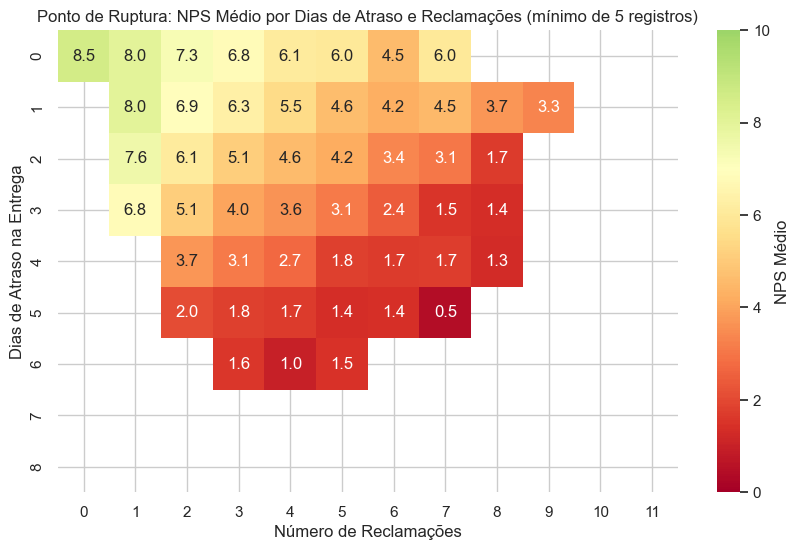

In [138]:
# Vamos mascarar células com menos de 5 registros
LIMITE_MINIMO = 5
mascara = matriz_qtd < LIMITE_MINIMO

plt.figure(figsize=(10, 6))

# 4. Desenhar o Heatmap mascarado
sns.heatmap(
    matriz_nps,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    vmax=10,
    vmin=0,
    center=7.0,
    mask=mascara,
    cbar_kws={'label': 'NPS Médio'},
)

plt.title(f'Ponto de Ruptura: NPS Médio por Dias de Atraso e Reclamações (mínimo de {LIMITE_MINIMO} registros)')
plt.xlabel('Número de Reclamações')
plt.ylabel('Dias de Atraso na Entrega')

plt.savefig('../reports/figures/ponto_de_ruptura_minimo_5_registros.png', dpi=300, bbox_inches='tight')

plt.show()

In [139]:
# Nossa análise já está bastante robusta em torno do que julgamos coerente analisar. Cabe darmos uma olhada no perfil dos clientes apenas, 
# para nos certificarmos que não temos impacto na nota do NPS devido a isso

In [140]:
perfil_clientes = df.groupby('grupo_nps')[[
    'idade_cliente', 
    'tempo_relacionamento_cliente', 
    'valor_pedido'
]].mean().reindex(['Promotor', 'Neutro', 'Detrator'])

perfil_clientes

,idade_cliente,tempo_relacionamento_cliente,valor_pedido
grupo_nps,,,
Promotor,43.627273,63.000000,468.084182
Neutro,43.252669,59.832740,458.171779
Detrator,43.403035,61.433381,429.309540


In [141]:
# O perfil dos clientes é praticamente o mesmo, o que indica que de fato o problema gira em torno de uma experiência operacional

In [142]:
# Para finalizar, vamos averiguar que não estamos deixando passar nenhum viés de região
dados_por_regiao = df.groupby('regiao_cliente').agg(
    qtd_pedidos=('id_pedido', 'count'),
    nps_medio=('nota_nps', 'mean'),
    atraso_medio=('dias_atraso_entrega', 'mean'),
    reclamacoes_medias=('qtd_reclamacoes', 'mean')
).reset_index()

dados_por_regiao

,regiao_cliente,qtd_pedidos,nps_medio,atraso_medio,reclamacoes_medias
0,Centro-Oeste,468,4.209829,2.222222,4.177350
1,Nordeste,485,4.421649,2.185567,4.162887
2,Norte,506,4.382609,2.144269,4.110672
3,Sudeste,520,4.373846,2.217308,4.242308
4,Sul,521,4.490979,2.168906,4.061420


In [143]:
# Também não existem problemas notórios a primeira vista que sejam relativos a localização dos clientes

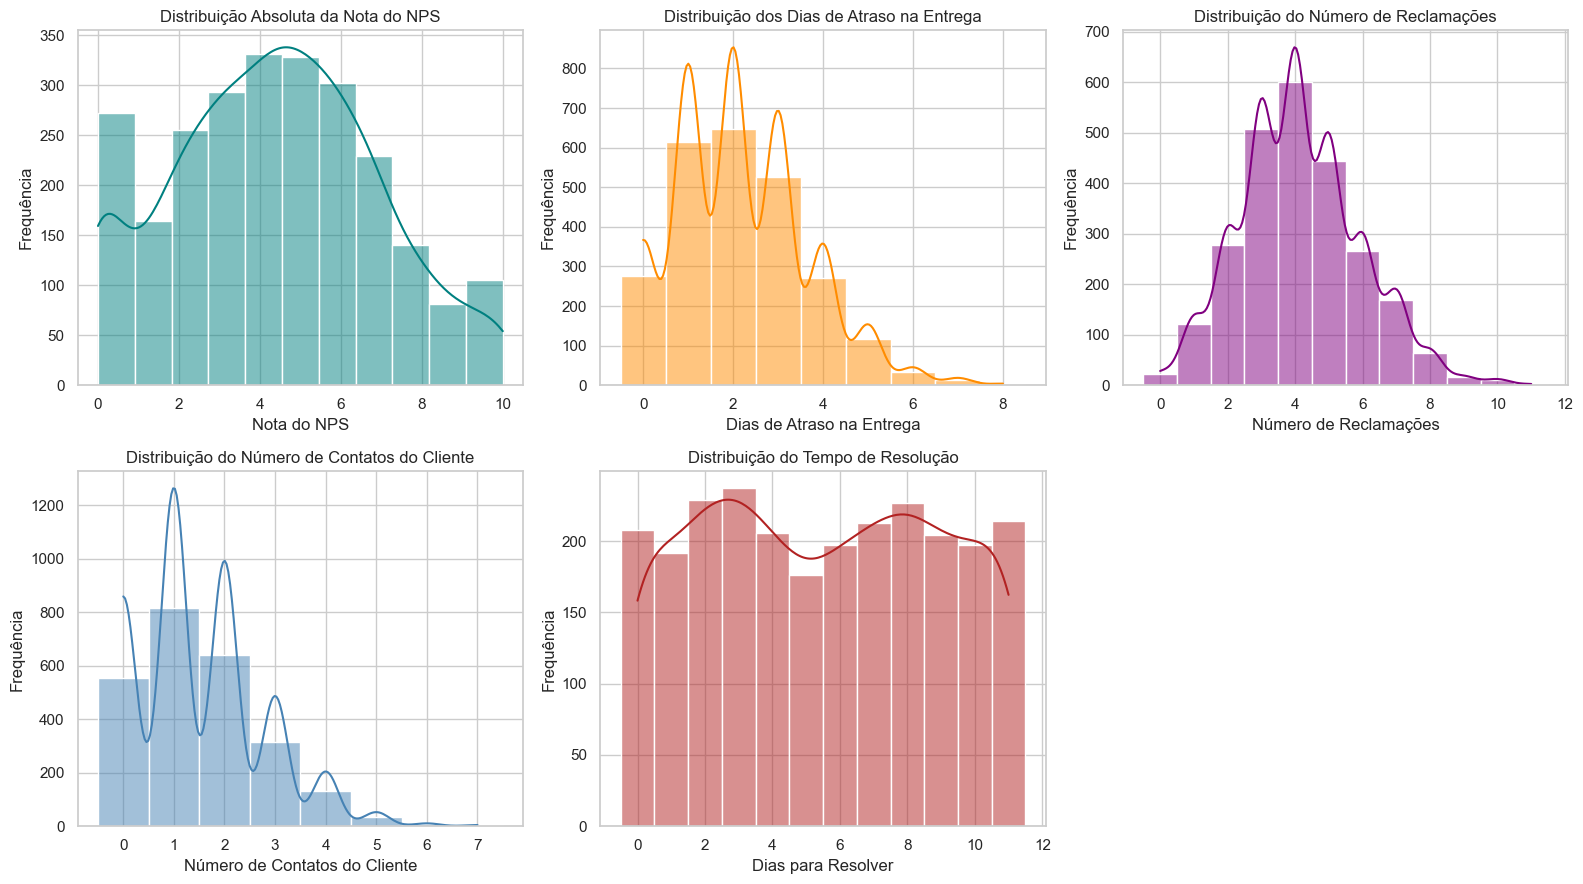

In [144]:
# Por fim, para complementar as análises, geramos a distribuição de frequência das principais variáveis do dataset.
# O objetivo aqui é compreender o comportamento, a variabilidade e a concentração dos dados antes da modelagem preditiva em si
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Distribuição das notas do NPS
sns.histplot(df['nota_nps'], kde=True, bins=11, color='teal', ax=axes[0, 0])
axes[0, 0].set_title('Distribuição Absoluta da Nota do NPS')
axes[0, 0].set_xlabel('Nota do NPS')
axes[0, 0].set_ylabel('Frequência')

# Distribuição dos dias de atraso
sns.histplot(df['dias_atraso_entrega'], discrete=True, kde=True, color='darkorange', ax=axes[0, 1])
axes[0, 1].set_title('Distribuição dos Dias de Atraso na Entrega')
axes[0, 1].set_xlabel('Dias de Atraso na Entrega')
axes[0, 1].set_ylabel('Frequência')

# Distribuição do número de reclamações
sns.histplot(df['qtd_reclamacoes'], discrete=True, kde=True, color='purple', ax=axes[0, 2])
axes[0, 2].set_title('Distribuição do Número de Reclamações')
axes[0, 2].set_xlabel('Número de Reclamações')
axes[0, 2].set_ylabel('Frequência')

# Distribuição do número de contatos do cliente
sns.histplot(df['contatos_sac'], discrete=True, kde=True, color='steelblue', ax=axes[1, 0])
axes[1, 0].set_title('Distribuição do Número de Contatos do Cliente')
axes[1, 0].set_xlabel('Número de Contatos do Cliente')
axes[1, 0].set_ylabel('Frequência')

# Distribuição do tempo de resolução
sns.histplot(df['tempo_resolucao_dias'], discrete=True, kde=True, color='firebrick', ax=axes[1, 1])
axes[1, 1].set_title('Distribuição do Tempo de Resolução')
axes[1, 1].set_xlabel('Dias para Resolver')
axes[1, 1].set_ylabel('Frequência')

# Remove o espaço vazio do canto inferior direito
fig.delaxes(axes[1, 2])

plt.tight_layout()

plt.savefig('../reports/figures/distribuicoes_operacionais.png', dpi=300, bbox_inches='tight')

plt.show()

In [145]:
# Conclusão das distribuições de frequências:
# 1. Nota do NPS: concentração alta entre 3 e 6 confirma viés de insatisfação (maioria de detratores na base).
# 2. Dias de Atraso: concentrado em pequenos atrasos (1 a 3 dias), indicando onde a operação sofre o principal gargalo.
# 3. Número de Reclamações: segue uma distribuição normal centrada em 4 reclamações, validando as premissas para os modelos preditivos.
# 4. Contatos do Cliente: queda brusca após o 2º contato, demonstra que a insatisfação atinge o pico logo nos primeiros acionamentos.
# 5. Tempo de Resolução: distribuição uniforme mostra falta de padronização e previsibilidade no tempo de atendimento do SAC.